   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00
HMM-BASED VOLATILITY REGIME MODELING

VOLATILITY STATE STATISTICS
 State  Observations  Mean 5D Vol (%)  Mean 20D Vol (%)  Mean 60D Vol (%)  Vol Ratio
     0           984          10.4128           11.2287           12.2110     0.9297
     1          1018          10.4200           11.3245           12.3046     0.9215
     2           646          20.9513           22.6663           21.8186     0.9456

TRANSITION MATRIX
         State 0  State 1  State 2
State 0   0.0000    1.000   0.0000
State 1   0.9668    0.000   0.0332
State 2   0.0000    0.053   0.9470

REGIME PERSISTENCE & EXPECTED DURATION
 State            Regime  Stay Probability  Expected Duration (Days)
     0    Low Volatility             0.000                    1.0000
     1 Medium Volatility             0.000                    1.0000
     2   High Volatility             0.947                   18.8577

CURRENT VOLATILITY REGIME
------------

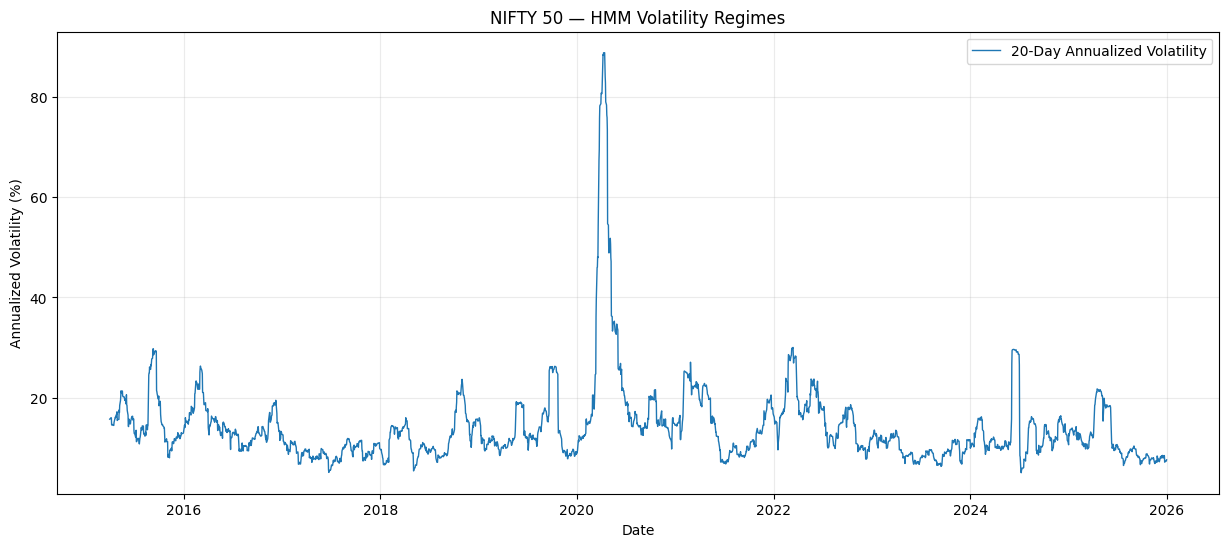

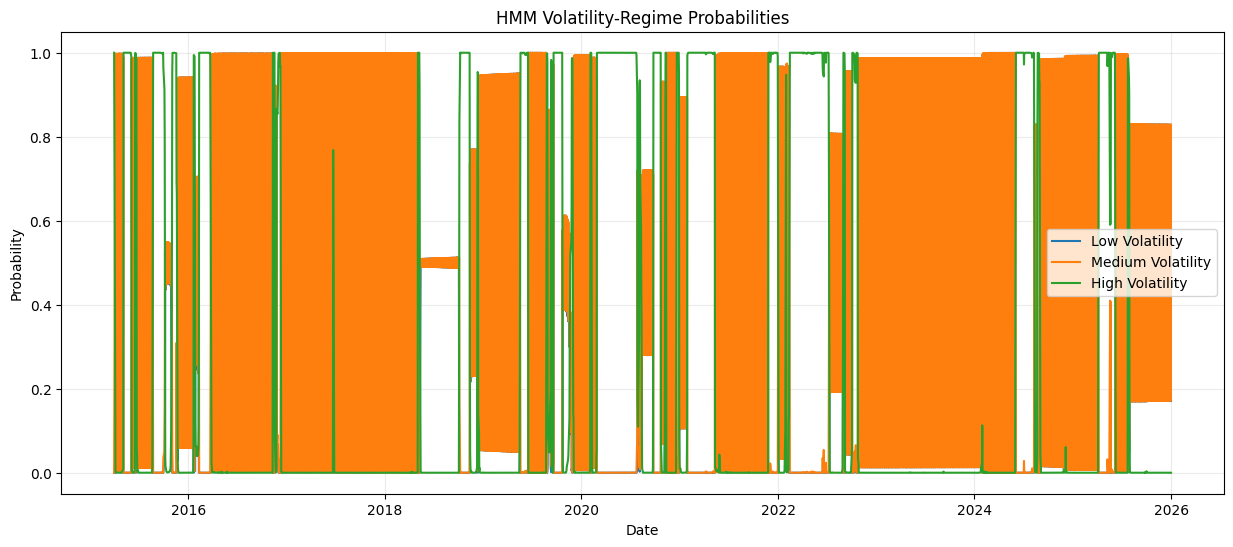

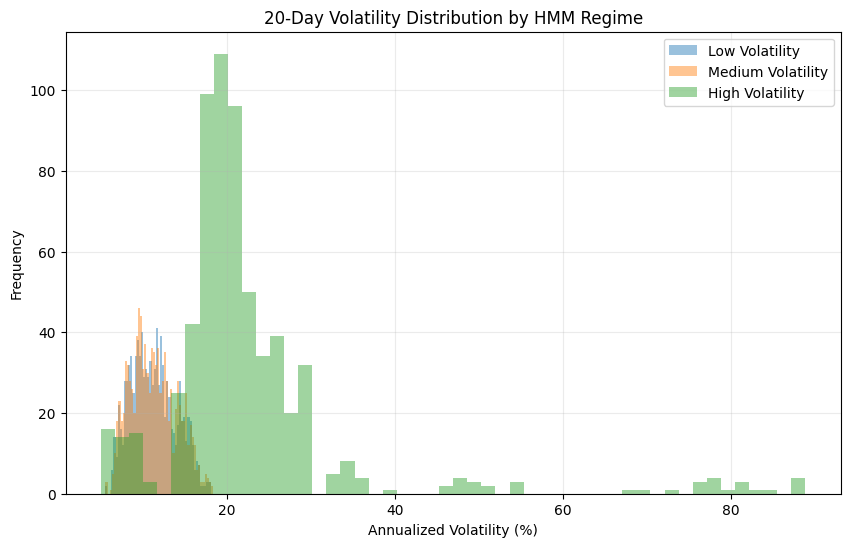


Saved:
NIFTY50_HMM_Volatility_Regimes.csv


In [1]:
# ============================================================
# PROJECT 3 — HMM-BASED VOLATILITY REGIME MODELING
# NIFTY 50
# ============================================================

!pip -q install yfinance hmmlearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. DOWNLOAD NIFTY 50 DATA
# ------------------------------------------------------------
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

# ------------------------------------------------------------
# 2. VOLATILITY FEATURES
# ------------------------------------------------------------
df["Return"] = df["Close"].pct_change()

df["Vol_5D"] = (
    df["Return"]
    .rolling(5)
    .std() * np.sqrt(252)
)

df["Vol_20D"] = (
    df["Return"]
    .rolling(20)
    .std() * np.sqrt(252)
)

df["Vol_60D"] = (
    df["Return"]
    .rolling(60)
    .std() * np.sqrt(252)
)

df["Vol_Ratio"] = (
    df["Vol_5D"] / df["Vol_20D"]
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ------------------------------------------------------------
# 3. HMM INPUT
# ------------------------------------------------------------
features = [
    "Vol_5D",
    "Vol_20D",
    "Vol_60D",
    "Vol_Ratio"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    df[features]
)

# ------------------------------------------------------------
# 4. FIT GAUSSIAN HMM
# ------------------------------------------------------------
n_states = 3

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# ------------------------------------------------------------
# 5. HIDDEN VOLATILITY STATES
# ------------------------------------------------------------
df["State"] = model.predict(X)

probabilities = model.predict_proba(X)

for i in range(n_states):
    df[f"State_{i}_Prob"] = probabilities[:, i]

# ------------------------------------------------------------
# 6. STATE STATISTICS
# ------------------------------------------------------------
state_stats = []

for state in range(n_states):

    data = df[df["State"] == state]

    state_stats.append({
        "State": state,
        "Observations": len(data),
        "Mean 5D Vol (%)": data["Vol_5D"].mean() * 100,
        "Mean 20D Vol (%)": data["Vol_20D"].mean() * 100,
        "Mean 60D Vol (%)": data["Vol_60D"].mean() * 100,
        "Vol Ratio": data["Vol_Ratio"].mean()
    })

state_stats = pd.DataFrame(state_stats)

# ------------------------------------------------------------
# 7. LABEL VOLATILITY REGIMES
# ------------------------------------------------------------
ordered_states = (
    state_stats
    .sort_values("Mean 20D Vol (%)")
    ["State"]
    .tolist()
)

labels = [
    "Low Volatility",
    "Medium Volatility",
    "High Volatility"
]

state_mapping = {
    ordered_states[i]: labels[i]
    for i in range(n_states)
}

df["Volatility_Regime"] = (
    df["State"].map(state_mapping)
)

# ------------------------------------------------------------
# 8. TRANSITION MATRIX
# ------------------------------------------------------------
transition_matrix = pd.DataFrame(
    model.transmat_,
    index=[f"State {i}" for i in range(n_states)],
    columns=[f"State {i}" for i in range(n_states)]
)

# ------------------------------------------------------------
# 9. EXPECTED REGIME DURATION
# ------------------------------------------------------------
duration_data = []

for state in range(n_states):

    persistence = model.transmat_[state, state]

    if persistence < 1:
        expected_duration = 1 / (1 - persistence)
    else:
        expected_duration = np.inf

    duration_data.append({
        "State": state,
        "Regime": state_mapping[state],
        "Stay Probability": persistence,
        "Expected Duration (Days)": expected_duration
    })

duration_df = pd.DataFrame(duration_data)

# ------------------------------------------------------------
# 10. RESULTS
# ------------------------------------------------------------
print("=" * 70)
print("HMM-BASED VOLATILITY REGIME MODELING")
print("=" * 70)

print("\nVOLATILITY STATE STATISTICS")
print(
    state_stats
    .sort_values("Mean 20D Vol (%)")
    .round(4)
    .to_string(index=False)
)

print("\nTRANSITION MATRIX")
print(transition_matrix.round(4))

print("\nREGIME PERSISTENCE & EXPECTED DURATION")
print(
    duration_df
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 11. CURRENT VOLATILITY REGIME
# ------------------------------------------------------------
latest_state = df["State"].iloc[-1]

print("\nCURRENT VOLATILITY REGIME")
print("-" * 70)
print("Date:", df.index[-1].date())
print("Regime:", df["Volatility_Regime"].iloc[-1])

print("\nCurrent Regime Probabilities:")

for i in range(n_states):
    print(
        f"State {i} "
        f"({state_mapping[i]}): "
        f"{df[f'State_{i}_Prob'].iloc[-1] * 100:.2f}%"
    )

# ------------------------------------------------------------
# 12. VOLATILITY REGIMES OVER TIME
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Vol_20D"] * 100,
    linewidth=1,
    label="20-Day Annualized Volatility"
)

plt.title(
    "NIFTY 50 — HMM Volatility Regimes"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 13. HMM STATE PROBABILITIES
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

for i in range(n_states):

    plt.plot(
        df.index,
        df[f"State_{i}_Prob"],
        label=state_mapping[i]
    )

plt.title(
    "HMM Volatility-Regime Probabilities"
)

plt.xlabel("Date")
plt.ylabel("Probability")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 14. VOLATILITY DISTRIBUTION BY REGIME
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

for regime in labels:

    data = df[
        df["Volatility_Regime"] == regime
    ]["Vol_20D"] * 100

    plt.hist(
        data,
        bins=50,
        alpha=0.45,
        label=regime
    )

plt.title(
    "20-Day Volatility Distribution by HMM Regime"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------------------
df.to_csv(
    "NIFTY50_HMM_Volatility_Regimes.csv"
)

print("\nSaved:")
print("NIFTY50_HMM_Volatility_Regimes.csv")